In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [18]:
DATASET_PATH = r"E:\cell_images"

IMAGE_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 5

In [19]:
datagen = ImageDataGenerator(

    rescale=1/255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True
)

In [20]:
train_generator = datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMAGE_SIZE, IMAGE_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="binary",

    subset="training"

)

Found 22048 images belonging to 2 classes.


In [21]:
validation_generator = datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMAGE_SIZE, IMAGE_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="binary",

    subset="validation"

)

Found 5510 images belonging to 2 classes.


In [22]:
base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

In [23]:
base_model.trainable = False

In [24]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

output = Dense(

    1,

    activation="sigmoid"

)(x)

model = Model(

    inputs=base_model.input,

    outputs=output

)

In [25]:
model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [26]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS

)

C:\Users\ANINDITA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1221s 2s/step - accuracy: 0.6639 - loss: 0.6107 - val_accuracy: 0.8835 - val_loss: 0.3362
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 953s 1s/step - accuracy: 0.8599 - loss: 0.3371 - val_accuracy: 0.8951 - val_loss: 0.2795
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 859s 1s/step - accuracy: 0.8857 - loss: 0.2848 - val_accuracy: 0.9022 - val_loss: 0.2582
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1698s 2s/step - accuracy: 0.8955 - loss: 0.2611 - val_accuracy: 0.9083 - val_loss: 0.2441
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1051s 2s/step - accuracy: 0.9101 - loss: 0.2402 - val_accuracy: 0.9091 - val_loss: 0.2348


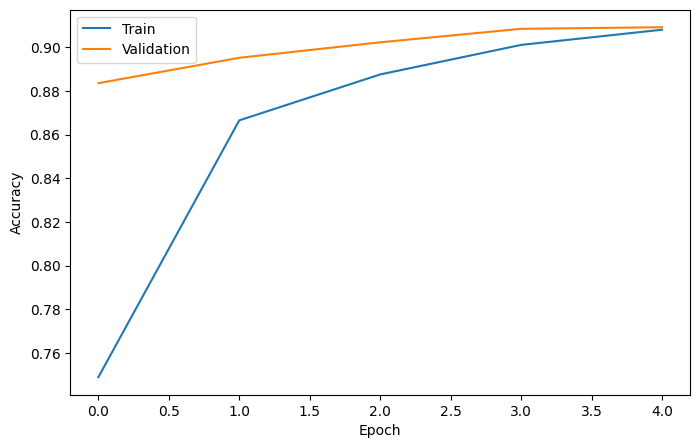

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

In [32]:
model.save(r"E:\trained_model.h5")
print("Model saved")

Model saved
